# K562 Off-target sgRNA analysis

Identify candidate off-target CRISPRi effects in Replogle et al. K562 data.
Adapted from `annotate_off_target.ipynb` for our CD4+ T cell data.

**Key differences from CD4 analysis:**
- No independent guide-1 / guide-2 — linked guide pairs target the same gene
- No guide concordance data → select follow-up perturbations by DE signal alone
- DE results from **DESeq2 h5ad** (`adata_k562`): zscore = log_fc / lfcSE capped at ±50
- Guide sequences come from `Replogle_k562_library_table.csv`, not `sgrna_df_final.csv`

**Pipeline:** KD detection → seed alignment → correlation validation

In [1]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import pearsonr
import scanpy as sc

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', None)

/Users/rzhu/miniconda3/envs/deseq/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/Users/rzhu/miniconda3/envs/deseq/lib/python3.11/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/Users/rzhu/miniconda3/envs/deseq/lib/python3.11/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


In [2]:
# ── Tunable parameters ────────────────────────────────────────────────────

# DE signal (must be met to warrant follow-up)
N_DE_GENES_THRESH = 0              # min significant DE genes per perturbation

# Seed search
SEED_LENGTH = 8                     # min seed length (3' end of spacer)
PROMOTER_UPSTREAM = 2000
PROMOTER_DOWNSTREAM = 2000
ADJ_PVAL_THRESH = 0.1               # significant DE threshold (DESeq2 adj p-value)
LFC_THRESH = 0                      # log_fc < this = downregulated
PROXIMAL_EXCLUDE_DIST = 2000        # exclude genes near sgRNA position
ZSCORE_CAP = 50                     # cap zscore at ± this value

# Off-target flagging thresholds
OFFTARGET_CORR_ALL_THRESH = 0.05     # min corr_de_all to flag as putative off-target
OFFTARGET_CORR_SIGNIF_THRESH = 0.2  # min corr_de_signif to flag
OFFTARGET_N_DE_SIGNIF_THRESH = 0   # min union n_de_signif to flag
OFFTARGET_PVAL_THRESH = 0.05        # max pval_de_signif to flag

# Paths
DESeq2_PATH = '../../../../3_expts/processed_data/analysis_largefiles/K562.merged_DE_results.h5ad'
TSS_MAP_CSV = '../../metadata/tss_map.csv'
GENOME_FA = '../../../../2_files/hg38_genome/hg38.fa'
GENOME_FAI = '../../../../2_files/hg38_genome/hg38.fa.fai'
OUT_DIR = Path('results_k562/')
OUT_DIR.mkdir(exist_ok=True)

## 1. Load data

In [3]:
# Load sgRNA library for guide sequences
k562_sgrna_df = pd.read_csv('../../metadata/Replogle_k562_library_table.csv')
adata_k562 = sc.read_h5ad(DESeq2_PATH, backed='r')

# Gene names from adata
gene_names_adata = adata_k562.var_names.values  # or var['gene_name'] if present
print(f'adata_k562: {adata_k562.shape} (perturbations x genes)')
print(f'  obs columns: {list(adata_k562.obs.columns)}')
print(f'  layers: {list(adata_k562.layers.keys())}')
print(f'k562_sgrna_df: {k562_sgrna_df.shape}')
print(f'Unique genes in library: {k562_sgrna_df["gene"].nunique()}')

adata_k562: (3081, 6294) (perturbations x genes)
  obs columns: ['culture_condition', 'target_contrast', 'chunk', 'target_contrast_gene_name', 'n_cells_target']
  layers: ['adj_p_value', 'baseMean', 'lfcSE', 'log_fc', 'p_value']
k562_sgrna_df: (11294, 10)
Unique genes in library: 9891


## 2. Profile helpers & spot-check plotting

Define `_get_profile` and `plot_zscore_scatter` early so you can compare any two
perturbation targets immediately after loading data — before running the full pipeline.

Profiles use **zscore = log_fc / lfcSE** capped at ±50.

In [4]:
# ── Build target name -> obs index mapping ──
# Use target_contrast_gene_name as the target identifier
target_col = 'target_contrast_gene_name'
target_names = adata_k562.obs[target_col].values
gene_names_col = gene_names_adata  # gene names from var

# Build target -> obs index lookup
target_to_idx = {}
for i, t in enumerate(target_names):
    if t not in target_to_idx:
        target_to_idx[t] = i
print(f'{len(target_to_idx)} unique perturbation targets in adata')

# ── Profile cache (zscore-based) ──
_cache = {}
def _get_profile(target):
    """Returns (zscore_vector, adj_pval_vector) for a perturbation target."""
    if target not in _cache:
        if target not in target_to_idx:
            _cache[target] = None
        else:
            idx = target_to_idx[target]
            lfc = np.asarray(adata_k562[idx].layers['log_fc']).flatten()
            lfcse = np.asarray(adata_k562[idx].layers['lfcSE']).flatten()
            adj_p = np.asarray(adata_k562[idx].layers['adj_p_value']).flatten()
            # zscore = log_fc / lfcSE, capped at ±ZSCORE_CAP
            with np.errstate(divide='ignore', invalid='ignore'):
                zscore = lfc / lfcse
            zscore = np.clip(zscore, -ZSCORE_CAP, ZSCORE_CAP)
            _cache[target] = (zscore, adj_p)
    return _cache[target]

def _corr(x, y, mask):
    v = mask & np.isfinite(x) & np.isfinite(y)
    n = int(v.sum())
    if n < 3:
        return np.nan, np.nan, n
    r, p = pearsonr(x[v], y[v])
    return r, p, n

# ── Scatter plot ──

def plot_zscore_scatter(target_1, target_2, adj_pval_thresh=ADJ_PVAL_THRESH,
                        figsize=(5, 5), save_path=None):
    """Scatter zscore of two perturbation targets."""
    c_ns, c_x_only, c_y_only, c_both = 'lightgray', '#1f77b4', '#ff7f0e', '#2ca02c'
    c_ontarget = '#e377c2'

    prof1 = _get_profile(target_1)
    prof2 = _get_profile(target_2)
    if prof1 is None:
        print(f'{target_1} not found'); return
    if prof2 is None:
        print(f'{target_2} not found'); return

    z1, pval1 = prof1
    z2, pval2 = prof2
    genes = gene_names_col.copy()

    finite = np.isfinite(z1) & np.isfinite(z2)
    z1, z2, pval1, pval2, genes = z1[finite], z2[finite], pval1[finite], pval2[finite], genes[finite]

    on_target = {target_1, target_2}
    ot_mask = np.isin(genes, list(on_target))
    corr_mask = ~ot_mask

    sig_x = pval1 < adj_pval_thresh
    sig_y = pval2 < adj_pval_thresh
    mask_both = sig_x & sig_y & corr_mask
    mask_x_only = sig_x & ~sig_y & corr_mask
    mask_y_only = ~sig_x & sig_y & corr_mask
    mask_ns = ~(sig_x | sig_y) & corr_mask

    fig, ax = plt.subplots(figsize=figsize)
    ax.scatter(z1[mask_ns], z2[mask_ns], c=c_ns, s=3, alpha=0.5, rasterized=True)
    ax.scatter(z1[mask_x_only], z2[mask_x_only], c=c_x_only, s=10, alpha=0.7, rasterized=True)
    ax.scatter(z1[mask_y_only], z2[mask_y_only], c=c_y_only, s=10, alpha=0.7, rasterized=True)
    ax.scatter(z1[mask_both], z2[mask_both], c=c_both, s=10, alpha=0.7, rasterized=True)

    if ot_mask.any():
        ax.scatter(z1[ot_mask], z2[ot_mask], c=c_ontarget, s=80, marker='D',
                   edgecolors='black', linewidth=1.5, zorder=11)
        for gn in genes[ot_mask]:
            gi = np.where(genes == gn)[0]
            if len(gi):
                ax.annotate(gn, (z1[gi[0]], z2[gi[0]]), fontsize=12, xytext=(4, 4),
                            textcoords='offset points', color=c_ontarget, fontweight='bold')

    v = corr_mask & np.isfinite(z1) & np.isfinite(z2)
    r_all, p_all = pearsonr(z1[v], z2[v]) if v.sum() > 2 else (np.nan, np.nan)
    vs = v & (sig_x | sig_y)
    r_sig, p_sig = pearsonr(z1[vs], z2[vs]) if vs.sum() > 2 else (np.nan, np.nan)

    ax.axhline(0, color='k', linestyle=':', alpha=0.3)
    ax.axvline(0, color='k', linestyle=':', alpha=0.3)
    ax.set_xlabel(f'{target_1} zscore', fontsize=14)
    ax.set_ylabel(f'{target_2} zscore', fontsize=14)
    ax.tick_params(labelsize=12)
    title = f'All: R={r_all:.2f}, p={p_all:.1e}'
    if vs.sum() > 2:
        title += f'\nUnion Sig: R={r_sig:.2f}, p={p_sig:.1e}'
    ax.set_title(title, fontsize=14)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f'Saved to {save_path}')
    plt.show()

print('Profile helpers and plot_zscore_scatter loaded.')

3081 unique perturbation targets in adata
Profile helpers and plot_zscore_scatter loaded.


## 3. Build sgRNA lookup from K562 library

Map each target gene to all guide sequences used in the experiment.
Parse guide genomic positions from sgID format for proximal filtering.

In [5]:
# Build target -> list of (guide_id, sequence) mapping
# Each row in k562_sgrna_df contributes guide A and guide B
target_guides = {}  # gene -> [(sgID, seq), ...]
for _, row in k562_sgrna_df.iterrows():
    gene = row['gene']
    if gene == 'non-targeting':
        continue
    if gene not in target_guides:
        target_guides[gene] = []
    target_guides[gene].append((row['sgID_A'], row['targeting sequence A']))
    target_guides[gene].append((row['sgID_B'], row['targeting sequence B']))

# Deduplicate guide sequences per target (some genes have duplicated guide pairs)
for gene in target_guides:
    target_guides[gene] = list(set(target_guides[gene]))

# Also build flat sgRNA lookup: sgID -> sequence
sgrna_lookup = {}
for guides in target_guides.values():
    for sgid, seq in guides:
        sgrna_lookup[sgid] = seq

# Parse guide positions from sgID format: "GENE_STRAND_POS.XX-PROMOTER"
def parse_sgid_position(sgid, tss_map):
    """Extract (chrom, pos) from sgID, using tss_map for chromosome lookup."""
    m = re.match(r'(.+)_([+-])_(\d+)\.\d+-.+', sgid)
    if not m:
        return None
    gene_name, strand, pos = m.group(1), m.group(2), int(m.group(3))
    tss_entry = tss_map.get(gene_name)
    if tss_entry is None:
        return None
    chrom = tss_entry[0]
    return (chrom, pos)

print(f'Built lookup for {len(target_guides)} target genes, {len(sgrna_lookup)} unique guides')
# Show example
example_gene = list(target_guides.keys())[0]
print(f'Example — {example_gene}: {len(target_guides[example_gene])} guides')
for sgid, seq in target_guides[example_gene][:4]:
    print(f'  {sgid}: {seq}')

Built lookup for 9890 target genes, 21418 unique guides
Example — A1BG: 4 guides
  A1BG_+_58858964.23-P1: GCTCCGGGCGACGTGGAGTG
  A1BG_-_58864822.23-P2: GATGATGGTCGCGCTCACTC
  A1BG_-_58858788.23-P1: GGGGCACCCAGGAGCGGTAG
  A1BG_-_58864840.23-P2: GCCGGTGCAGTGAGTGTCTG


## 4. Select follow-up perturbations

No guide concordance data available, so select based on DE signal alone:
perturbations with at least `N_DE_GENES_THRESH` significant DE genes (adj p-value).

In [6]:
# Count significant DE genes per perturbation (up + down) from adata
followup_targets = []

for target in target_to_idx:
    prof = _get_profile(target)
    if prof is None:
        continue
    _, adj_p = prof
    n_de = int((adj_p < ADJ_PVAL_THRESH).sum())
    if n_de >= N_DE_GENES_THRESH and target in target_guides:
        followup_targets.append({'target': target, 'n_de_genes': n_de})

followup_df = pd.DataFrame(followup_targets)
print(f'Total perturbation targets in adata: {len(target_to_idx)}')
print(f'With >= {N_DE_GENES_THRESH} DE genes AND in sgRNA library: {len(followup_df)}')
print(f'\nn_de_genes distribution:')
print(followup_df['n_de_genes'].describe())
followup_df.sort_values('n_de_genes', ascending=False).head(20)

Total perturbation targets in adata: 3081
With >= 0 DE genes AND in sgRNA library: 3081

n_de_genes distribution:
count    3081.000000
mean       20.343720
std        82.908765
min         0.000000
25%         2.000000
50%         5.000000
75%        15.000000
max      1767.000000
Name: n_de_genes, dtype: float64


,target,n_de_genes
253,MED19,1767
557,MED12,1558
318,DHX36,1473
142,TRRAP,1351
1371,GAB2,1194
1602,KRR1,1169
2936,ARGLU1,1067
1512,CMTR1,855
189,NELFCD,848
701,DOHH,811


## 5. Off-target pipeline functions

In [7]:
RC_MAP = str.maketrans('ACGTacgt', 'TGCAtgca')

# ── Loading helpers ──

def load_tss_map(csv_path, upstream=PROMOTER_UPSTREAM, downstream=PROMOTER_DOWNSTREAM):
    """gene_name -> (chrom, promoter_start, promoter_end)."""
    df = pd.read_csv(csv_path)
    tss_map = {}
    for _, row in df.iterrows():
        tss_0 = int(row['tss']) - 1
        if row.get('strand', '+') == '+':
            pstart, pend = tss_0 - upstream, tss_0 + downstream
        else:
            pstart, pend = tss_0 - downstream, tss_0 + upstream
        tss_map[row['gene_name']] = (row['chrom'], max(0, pstart), pend)
    return tss_map

def load_tss_coords(csv_path):
    """gene_name -> (chrom, tss_position)."""
    df = pd.read_csv(csv_path)
    return {row['gene_name']: (row['chrom'], int(row['tss'])) for _, row in df.iterrows()}

def load_fai(fai_path):
    fai = {}
    with open(fai_path) as fh:
        for line in fh:
            parts = line.rstrip().split('\t')
            if len(parts) >= 5:
                fai[parts[0]] = (int(parts[1]), int(parts[2]), int(parts[3]), int(parts[4]))
    return fai

def is_proximal_to_guide(guide_locs, gene_name, tss_coords, max_dist):
    coord = tss_coords.get(gene_name)
    if coord is None:
        return False
    gene_chrom, gene_tss = coord
    return any(gc == gene_chrom and abs(gp - gene_tss) <= max_dist
               for gc, gp in guide_locs)

# ── Genome sequence extraction ──

def extract_genome_region(fai_dict, chrom, start, end, genome_path):
    if chrom not in fai_dict:
        return ''
    chrom_len, fai_offset, linebases, linewidth = fai_dict[chrom]
    start, end = max(0, start), min(chrom_len, end)
    if start >= end:
        return ''
    byte_start = fai_offset + (start // linebases) * linewidth + (start % linebases)
    byte_last = fai_offset + ((end - 1) // linebases) * linewidth + ((end - 1) % linebases)
    with open(genome_path, 'rb') as fh:
        fh.seek(byte_start)
        raw = fh.read(byte_last - byte_start + 1)
    return raw.decode('ascii', errors='ignore').replace('\n', '').replace('\r', '')[:end - start].upper()

# ── Seed matching ──

def revcomp(seq):
    return seq.translate(RC_MAP)[::-1]

def find_max_seed_match(full_spacer, promoter_seq, min_len=5):
    """Longest 3'-end seed with a PAM-adjacent match in promoter (either strand).
    Returns (seed_len, hamming_dist, local_pos, strand)."""
    best, best_info = 0, None
    spacer_len = len(full_spacer)
    seq_up = promoter_seq.upper()
    for length in range(min_len, spacer_len + 1):
        seed = full_spacer[-length:].upper()
        rc_seed = revcomp(seed)
        m_fwd = re.search(re.escape(seed) + r'[ACGT]GG', seq_up)
        m_rev = re.search(r'CC[ACGT]' + re.escape(rc_seed), seq_up)
        if m_fwd:
            best, best_info = length, ('fwd', m_fwd.start())
        elif m_rev:
            best, best_info = length, ('rev', m_rev.start())
    if best == 0 or best_info is None:
        return 0, None, None, None
    strand_dir, p = best_info
    if strand_dir == 'fwd':
        g_start = p - (spacer_len - best)
        genomic = ('N' * max(0, -g_start) + seq_up[max(0, g_start):p + best])[:spacer_len]
        strand_char = '+'
    else:
        s_end = p + 3 + spacer_len
        site_fwd = seq_up[p + 3:s_end] if s_end <= len(seq_up) else seq_up[p + 3:] + 'N' * (s_end - len(seq_up))
        genomic = revcomp(site_fwd)
        strand_char = '-'
    hamming = sum(a != b for a, b in zip(full_spacer.upper(), genomic))
    return best, hamming, p, strand_char

# ── Per-target downregulated genes (from adata) ──

def get_downregulated_genes(target, adj_pval_thresh=ADJ_PVAL_THRESH, lfc_thresh=LFC_THRESH):
    """Returns list of (gene, lfc, adj_pval) for significantly downregulated genes."""
    if target not in target_to_idx:
        return []
    idx = target_to_idx[target]
    lfc = np.asarray(adata_k562[idx].layers['log_fc']).flatten()
    adj_p = np.asarray(adata_k562[idx].layers['adj_p_value']).flatten()
    sig_down = (adj_p < adj_pval_thresh) & (lfc < lfc_thresh)
    return [(gene_names_col[i], lfc[i], adj_p[i]) for i in np.where(sig_down)[0]]

# ── Search one guide's seed against downregulated gene promoters ──

def search_guide_seeds(guide_id, spacer_seq, downreg_genes, tss_map,
                       fai_dict, genome_path, seed_length=SEED_LENGTH):
    if not spacer_seq:
        return []
    hits = []
    for gene_name, lfc, adj_p in downreg_genes:
        coords = tss_map.get(gene_name)
        if coords is None:
            continue
        chrom, pstart, pend = coords
        prom_seq = extract_genome_region(fai_dict, chrom, pstart, pend, genome_path)
        if not prom_seq:
            continue
        match_len, hamming, local_pos, strand = find_max_seed_match(spacer_seq, prom_seq, min_len=5)
        if match_len >= seed_length:
            hits.append({
                'guide_id': guide_id, 'spacer_seq': spacer_seq,
                'downreg_gene': gene_name, 'log_fc': lfc, 'adj_pval': adj_p,
                'seed_match_len': match_len, 'hamming_dist': hamming,
                'match_strand': strand, 'match_chrom': chrom,
                'match_pos': pstart + local_pos if local_pos is not None else None,
                'seed_seq': spacer_seq[-match_len:].upper(),
            })
    return hits

# ── Main pipeline ──

def run_offtarget_pipeline(followup_df, target_guides, tss_map, tss_coords,
                           fai_dict, genome_path, seed_length=SEED_LENGTH,
                           proximal_exclude_dist=PROXIMAL_EXCLUDE_DIST):
    all_hits, n_proximal = [], 0
    n_total = len(followup_df)
    for i, (_, row) in enumerate(followup_df.iterrows()):
        target = row['target']
        downreg = get_downregulated_genes(target)
        # Exclude on-target gene
        downreg = [(g, l, p) for g, l, p in downreg if g != target]
        if not downreg:
            continue
        guides = target_guides.get(target, [])
        for sgid, seq in guides:
            # Proximal filtering: exclude genes near this guide's position
            if proximal_exclude_dist > 0:
                guide_loc = parse_sgid_position(sgid, tss_map)
                if guide_loc is not None:
                    before = len(downreg)
                    downreg_filt = [(g, l, p) for g, l, p in downreg
                                   if not is_proximal_to_guide([guide_loc], g, tss_coords, proximal_exclude_dist)]
                    n_proximal += before - len(downreg_filt)
                else:
                    downreg_filt = downreg
            else:
                downreg_filt = downreg
            if not downreg_filt:
                continue
            hits = search_guide_seeds(sgid, seq, downreg_filt, tss_map,
                                      fai_dict, genome_path, seed_length=seed_length)
            for h in hits:
                h['target'] = target
            all_hits.extend(hits)
        if (i + 1) % 200 == 0 or (i + 1) == n_total:
            print(f'  {i+1}/{n_total}, {len(all_hits)} hits', flush=True)
    print(f'  Excluded {n_proximal} proximal genes (within {proximal_exclude_dist}bp of sgRNA)')
    if not all_hits:
        print('No off-target seed matches found.')
        return pd.DataFrame()
    results = pd.DataFrame(all_hits)
    col_order = ['target', 'guide_id', 'spacer_seq',
                 'downreg_gene', 'log_fc', 'adj_pval',
                 'seed_match_len', 'hamming_dist', 'seed_seq',
                 'match_strand', 'match_chrom', 'match_pos']
    return results[[c for c in col_order if c in results.columns]].sort_values(
        ['seed_match_len', 'log_fc'], ascending=[False, True]).reset_index(drop=True)

print('Functions loaded.')

Functions loaded.


## 6. Run off-target seed search

In [8]:
tss_map = load_tss_map(TSS_MAP_CSV)
tss_coords = load_tss_coords(TSS_MAP_CSV)
fai_dict = load_fai(GENOME_FAI)
print(f'{len(tss_map)} TSS entries, {len(fai_dict)} chromosomes')

results = run_offtarget_pipeline(
    followup_df, target_guides, tss_map, tss_coords,
    fai_dict, GENOME_FA)
print(f'\nTotal candidate hits: {len(results)}')
results.head(20)

20509 TSS entries, 455 chromosomes
  400/3081, 82 hits
  1000/3081, 216 hits
  1200/3081, 276 hits
  1600/3081, 359 hits
  2800/3081, 606 hits
  Excluded 2 proximal genes (within 2000bp of sgRNA)

Total candidate hits: 668


,target,guide_id,spacer_seq,downreg_gene,log_fc,adj_pval,seed_match_len,hamming_dist,seed_seq,match_strand,match_chrom,match_pos
0,NDUFS1,NDUFS1_+_207024173.23-P1P2,GGCTTTCCGTTCTCCAGGCC,EEF1B2,-3.782880,8.917813e-02,20,0,GGCTTTCCGTTCTCCAGGCC,-,chr2,206159449
1,OPN3,OPN3_-_241803628.23-P1P2,GCTCGCGGCGCGCTCCGCAC,CHML,-3.423184,1.207552e-02,20,0,GCTCGCGGCGCGCTCCGCAC,+,chr1,241640304
2,ZCCHC17,ZCCHC17_-_31769872.23-P1P2,GGAAACGCGCTGGCTGACTG,SNRNP40,-3.308801,7.128260e-02,20,0,GGAAACGCGCTGGCTGACTG,+,chr1,31297003
3,NUDCD2,NUDCD2_+_162887114.23-P1P2,GCCGAGGCGTAGCCTAAGCG,HMMR,-2.823104,4.104123e-05,20,0,GCCGAGGCGTAGCCTAAGCG,-,chr5,163460108
4,XRRA1,XRRA1_-_74660140.23-P1P2,GACGCGACGGCAGACAGTGT,SPCS2,-2.692188,1.107778e-07,20,0,GACGCGACGGCAGACAGTGT,+,chr11,74949073
5,GMPR2,GMPR2_-_24702203.23-P1P2,GGGTAAGGAATGCACCGTCA,NEDD8,-2.542413,6.079383e-10,20,0,GGGTAAGGAATGCACCGTCA,+,chr14,24232975
6,RBM10,RBM10_-_47004526.23-P1P2,GGAGCGTTCGCAAGGGGTGT,NDUFB11,-2.378474,8.068917e-20,20,0,GGAGCGTTCGCAAGGGGTGT,+,chrX,47145105
7,RBM10,RBM10_+_47004643.23-P1P2,GGCGACGACGAGAAGGGAGT,NDUFB11,-2.378474,8.068917e-20,20,0,GGCGACGACGAGAAGGGAGT,-,chrX,47145244
8,KCTD9,KCTD9_+_25315923.23-P1P2,GACCGGCCGAACCTTGGGTG,CDCA2,-2.367562,7.098377e-02,20,0,GACCGGCCGAACCTTGGGTG,-,chr8,25458407
9,FEN1,FEN1_+_61560617.23-P1P2,GACTGGCCCAAGGCTCACAG,TMEM258,-2.275704,1.366445e-26,20,0,GACTGGCCCAAGGCTCACAG,-,chr11,61793145


In [47]:
results.to_csv(OUT_DIR / 'candidate_offtarget_genes.csv', index=False)
print(f'Saved {len(results)} hits to {OUT_DIR / "candidate_offtarget_genes.csv"}')

Saved 668 hits to results_k562/candidate_offtarget_genes.csv


## 7. Correlation validation

Correlate each perturbation's **zscore profile** with the candidate off-target gene's
zscore profile. Only possible when the candidate gene is itself a perturbation target.

In [9]:
# Main correlation loop (uses _get_profile and _corr from section 2)
corr_rows = []
n_skip = 0
for _, row in results.iterrows():
    target, downreg_gene = row['target'], row['downreg_gene']
    prof_pert = _get_profile(target)
    prof_ot = _get_profile(downreg_gene)

    rec = {k: row[k] for k in ['target', 'guide_id', 'downreg_gene',
                                'seed_match_len', 'hamming_dist', 'log_fc', 'adj_pval']}

    if prof_pert is None or prof_ot is None:
        n_skip += 1
        rec.update(corr_de_all=np.nan, pval_de_all=np.nan,
                   corr_de_signif=np.nan, pval_de_signif=np.nan, n_de_signif=0)
        corr_rows.append(rec)
        continue

    z_pert, pval_pert = prof_pert
    z_ot, pval_ot = prof_ot

    # Exclude on-target and focal off-target gene from correlation
    keep = np.array([g not in {target, downreg_gene} for g in gene_names_col])

    # Correlation on all genes (zscore)
    r_all, pv_all, _ = _corr(z_pert, z_ot, keep)
    # Correlation on union-significant genes
    signif = (pval_pert < ADJ_PVAL_THRESH) | (pval_ot < ADJ_PVAL_THRESH)
    r_sig, pv_sig, n_sig = _corr(z_pert, z_ot, keep & signif)

    rec.update(
        corr_de_all=round(r_all, 4) if np.isfinite(r_all) else np.nan,
        pval_de_all=pv_all if np.isfinite(pv_all) else np.nan,
        corr_de_signif=round(r_sig, 4) if np.isfinite(r_sig) else np.nan,
        pval_de_signif=pv_sig if np.isfinite(pv_sig) else np.nan,
        n_de_signif=n_sig)
    corr_rows.append(rec)

corr_results = pd.DataFrame(corr_rows)
# Combined p-value (min of all and signif)
corr_results['pval_signif_min'] = corr_results[['pval_de_all', 'pval_de_signif']].min(axis=1)

print(f'Correlation results: {len(corr_results)} rows')
print(f'  Skipped (candidate gene not a perturbation target): {n_skip}')
print(f'  With valid correlation: {corr_results["corr_de_all"].notna().sum()}')
corr_results.sort_values('corr_de_signif', ascending=False).head(20)

Correlation results: 668 rows
  Skipped (candidate gene not a perturbation target): 395
  With valid correlation: 273


,target,guide_id,downreg_gene,seed_match_len,hamming_dist,log_fc,adj_pval,corr_de_all,pval_de_all,corr_de_signif,pval_de_signif,n_de_signif,pval_signif_min
558,RAC2,RAC2_-_37640109.23-P1P2,NUCKS1,8,12,-0.454727,2.467178e-03,0.0806,1.507078e-10,0.9850,5.229269e-05,7,1.507078e-10
112,TGFB1,TGFB1_-_41859819.23-P1P2,TCEAL8,12,7,-1.435266,7.820461e-04,0.0434,5.687508e-04,0.9814,1.230965e-01,3,5.687508e-04
51,STYXL1,STYXL1_+_75677069.23-P1P2,MDH2,19,1,-1.785835,1.464235e-43,0.0059,6.390145e-01,0.8994,3.772301e-02,5,3.772301e-02
17,STYXL1,STYXL1_+_75677277.23-P1P2,MDH2,20,0,-1.785835,1.464235e-43,0.0059,6.390145e-01,0.8994,3.772301e-02,5,3.772301e-02
208,ABHD14B,ABHD14B_-_52008040.23-P1,ZNF12,11,6,-1.216368,3.988989e-11,0.0525,3.108547e-05,0.7692,7.372940e-02,6,3.108547e-05
215,RNF10,RNF10_+_120972578.23-P1P2,MSH2,11,8,-1.104034,1.331595e-04,0.0337,7.442829e-03,0.5694,6.750098e-02,11,7.442829e-03
413,PINK1,PINK1_-_20960044.23-P1P2,FUOM,9,7,-0.506044,4.606518e-14,-0.0082,5.145108e-01,0.5216,1.310607e-03,35,1.310607e-03
550,PINK1,PINK1_-_20960047.23-P1P2,FUOM,8,5,-0.506044,4.606518e-14,-0.0082,5.145108e-01,0.5216,1.310607e-03,35,1.310607e-03
264,MIDN,MIDN_-_1248697.23-P2,CRKL,11,6,-0.444823,1.507377e-03,0.0530,2.591346e-05,0.5125,1.941051e-01,8,2.591346e-05
222,CENPW,CENPW_-_126661477.23-P1P2,MARCKSL1,11,8,-1.009940,1.993975e-02,-0.0210,9.520626e-02,0.4992,1.940757e-03,36,1.940757e-03


In [10]:
corr_results.to_csv(OUT_DIR / 'candidate_offtarget_correlation.csv', index=False)
print(f'Saved to {OUT_DIR / "candidate_offtarget_correlation.csv"}')

corr_results.sort_values('corr_de_signif', ascending=False).head(30)

Saved to results_k562/candidate_offtarget_correlation.csv


,target,guide_id,downreg_gene,seed_match_len,hamming_dist,log_fc,adj_pval,corr_de_all,pval_de_all,corr_de_signif,pval_de_signif,n_de_signif,pval_signif_min
558,RAC2,RAC2_-_37640109.23-P1P2,NUCKS1,8,12,-0.454727,2.467178e-03,0.0806,1.507078e-10,0.9850,5.229269e-05,7,1.507078e-10
112,TGFB1,TGFB1_-_41859819.23-P1P2,TCEAL8,12,7,-1.435266,7.820461e-04,0.0434,5.687508e-04,0.9814,1.230965e-01,3,5.687508e-04
51,STYXL1,STYXL1_+_75677069.23-P1P2,MDH2,19,1,-1.785835,1.464235e-43,0.0059,6.390145e-01,0.8994,3.772301e-02,5,3.772301e-02
17,STYXL1,STYXL1_+_75677277.23-P1P2,MDH2,20,0,-1.785835,1.464235e-43,0.0059,6.390145e-01,0.8994,3.772301e-02,5,3.772301e-02
208,ABHD14B,ABHD14B_-_52008040.23-P1,ZNF12,11,6,-1.216368,3.988989e-11,0.0525,3.108547e-05,0.7692,7.372940e-02,6,3.108547e-05
215,RNF10,RNF10_+_120972578.23-P1P2,MSH2,11,8,-1.104034,1.331595e-04,0.0337,7.442829e-03,0.5694,6.750098e-02,11,7.442829e-03
413,PINK1,PINK1_-_20960044.23-P1P2,FUOM,9,7,-0.506044,4.606518e-14,-0.0082,5.145108e-01,0.5216,1.310607e-03,35,1.310607e-03
550,PINK1,PINK1_-_20960047.23-P1P2,FUOM,8,5,-0.506044,4.606518e-14,-0.0082,5.145108e-01,0.5216,1.310607e-03,35,1.310607e-03
264,MIDN,MIDN_-_1248697.23-P2,CRKL,11,6,-0.444823,1.507377e-03,0.0530,2.591346e-05,0.5125,1.941051e-01,8,2.591346e-05
222,CENPW,CENPW_-_126661477.23-P1P2,MARCKSL1,11,8,-1.009940,1.993975e-02,-0.0210,9.520626e-02,0.4992,1.940757e-03,36,1.940757e-03


## 8. Flag putative off-target cases

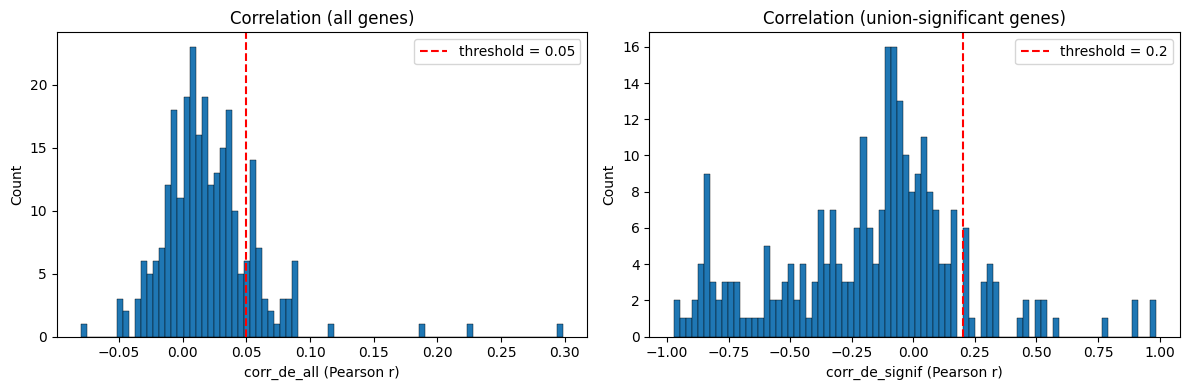

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(corr_results['corr_de_all'].dropna(), bins=80, edgecolor='black', linewidth=0.3)
ax.axvline(OFFTARGET_CORR_ALL_THRESH, color='red', linestyle='--', label=f'threshold = {OFFTARGET_CORR_ALL_THRESH}')
ax.set_xlabel('corr_de_all (Pearson r)')
ax.set_ylabel('Count')
ax.set_title('Correlation (all genes)')
ax.legend()

ax = axes[1]
ax.hist(corr_results['corr_de_signif'].dropna(), bins=80, edgecolor='black', linewidth=0.3)
ax.axvline(OFFTARGET_CORR_SIGNIF_THRESH, color='red', linestyle='--', label=f'threshold = {OFFTARGET_CORR_SIGNIF_THRESH}')
ax.set_xlabel('corr_de_signif (Pearson r)')
ax.set_ylabel('Count')
ax.set_title('Correlation (union-significant genes)')
ax.legend()

plt.tight_layout()
plt.show()

In [12]:
# Flag putative off-target cases (only among those with valid correlation)
flagged = corr_results[
    (corr_results['corr_de_all'] > OFFTARGET_CORR_ALL_THRESH) &
    (corr_results['corr_de_signif'] > OFFTARGET_CORR_SIGNIF_THRESH) &
    (corr_results['pval_de_signif'] < OFFTARGET_PVAL_THRESH) &
    (corr_results['n_de_signif'] > OFFTARGET_N_DE_SIGNIF_THRESH)
].copy().sort_values('pval_de_signif')

flagged.to_csv(OUT_DIR / 'putative_offtarget_hits.csv', index=False)
print(f'Flagged {len(flagged)} putative off-target hits')
print(f'  Criteria:')
print(f'  corr_de_all > {OFFTARGET_CORR_ALL_THRESH} & '
      f'corr_de_signif > {OFFTARGET_CORR_SIGNIF_THRESH} & '
      f'pval_de_signif < {OFFTARGET_PVAL_THRESH} & '
      f'n_de_signif > {OFFTARGET_N_DE_SIGNIF_THRESH}')
print(f'  Unique targets with flagged off-targets: {flagged["target"].nunique()}')
flagged

Flagged 9 putative off-target hits
  Criteria:
  corr_de_all > 0.05 & corr_de_signif > 0.2 & pval_de_signif < 0.05 & n_de_signif > 0
  Unique targets with flagged off-targets: 8


,target,guide_id,downreg_gene,seed_match_len,hamming_dist,log_fc,adj_pval,corr_de_all,pval_de_all,corr_de_signif,pval_de_signif,n_de_signif,pval_signif_min
477,MED19,MED19_+_57479662.23-P1P2,MYB,8,9,-1.028176,1.041653e-03,0.2988,6.212640e-130,0.3130,5.583642e-43,1835,6.212640e-130
161,EARS2,EARS2_+_23568615.23-P1P2,TMED10,11,5,-1.997466,1.627365e-07,0.2265,5.494103e-74,0.4483,1.393379e-08,146,5.494103e-74
278,COX17,COX17_-_119395995.23-P1P2,HSPD1,11,5,-0.200351,2.955715e-02,0.1157,3.247874e-20,0.3467,8.938750e-07,191,3.247874e-20
613,NOMO1,NOMO1_+_14927924.23-P1P2,MYB,8,9,-0.283006,8.638945e-02,0.1896,5.402367e-52,0.3212,1.200412e-06,219,5.402367e-52
577,TFDP1,TFDP1_+_114239040.23-P1P2,CD99,8,11,-0.374201,1.928511e-02,0.0872,4.170214e-12,0.2203,1.397718e-05,382,4.170214e-12
560,TFDP1,TFDP1_+_114239040.23-P1P2,TIPRL,8,11,-0.439555,4.995755e-02,0.0841,2.312045e-11,0.2198,1.455545e-05,382,2.312045e-11
558,RAC2,RAC2_-_37640109.23-P1P2,NUCKS1,8,12,-0.454727,2.467178e-03,0.0806,1.507078e-10,0.9850,5.229269e-05,7,1.507078e-10
664,FBXW7,FBXW7_-_153457248.23-ENST00000281708.4,HK1,8,12,-0.148325,9.054639e-02,0.0551,1.215826e-05,0.2323,2.065805e-02,99,1.215826e-05
190,PPARA,PPARA_-_46546638.23-P1P2,NDUFB10,11,4,-1.481519,1.955562e-25,0.0898,9.582106e-13,0.3204,2.995030e-02,46,9.582106e-13


## 9. Spot-check plots

In [13]:
flagged

,target,guide_id,downreg_gene,seed_match_len,hamming_dist,log_fc,adj_pval,corr_de_all,pval_de_all,corr_de_signif,pval_de_signif,n_de_signif,pval_signif_min
477,MED19,MED19_+_57479662.23-P1P2,MYB,8,9,-1.028176,1.041653e-03,0.2988,6.212640e-130,0.3130,5.583642e-43,1835,6.212640e-130
161,EARS2,EARS2_+_23568615.23-P1P2,TMED10,11,5,-1.997466,1.627365e-07,0.2265,5.494103e-74,0.4483,1.393379e-08,146,5.494103e-74
278,COX17,COX17_-_119395995.23-P1P2,HSPD1,11,5,-0.200351,2.955715e-02,0.1157,3.247874e-20,0.3467,8.938750e-07,191,3.247874e-20
613,NOMO1,NOMO1_+_14927924.23-P1P2,MYB,8,9,-0.283006,8.638945e-02,0.1896,5.402367e-52,0.3212,1.200412e-06,219,5.402367e-52
577,TFDP1,TFDP1_+_114239040.23-P1P2,CD99,8,11,-0.374201,1.928511e-02,0.0872,4.170214e-12,0.2203,1.397718e-05,382,4.170214e-12
560,TFDP1,TFDP1_+_114239040.23-P1P2,TIPRL,8,11,-0.439555,4.995755e-02,0.0841,2.312045e-11,0.2198,1.455545e-05,382,2.312045e-11
558,RAC2,RAC2_-_37640109.23-P1P2,NUCKS1,8,12,-0.454727,2.467178e-03,0.0806,1.507078e-10,0.9850,5.229269e-05,7,1.507078e-10
664,FBXW7,FBXW7_-_153457248.23-ENST00000281708.4,HK1,8,12,-0.148325,9.054639e-02,0.0551,1.215826e-05,0.2323,2.065805e-02,99,1.215826e-05
190,PPARA,PPARA_-_46546638.23-P1P2,NDUFB10,11,4,-1.481519,1.955562e-25,0.0898,9.582106e-13,0.3204,2.995030e-02,46,9.582106e-13


In [ ]:
# Example: plot top flagged hit (perturbation vs off-target gene)
if len(flagged) > 0:
    top = flagged.iloc[0]
    print(f'Top hit: {top["target"]} -> {top["downreg_gene"]} '
          f'(corr_all={top["corr_de_all"]:.3f}, corr_signif={top["corr_de_signif"]:.3f})')
    plot_zscore_scatter(top['target'], top['downreg_gene'])
else:
    print('No flagged hits to plot.')

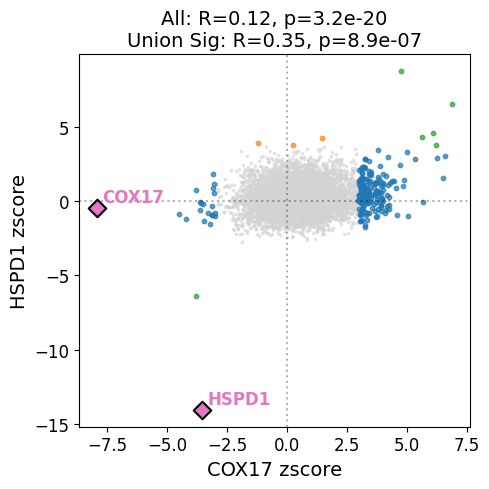

In [17]:
plot_zscore_scatter('COX17', 'HSPD1')